# Métodos de Diferencias Temporales (TD)

- `Joaquín Gayoso Filgueira - 205865`

En este notebook exploraremos métodos de diferencias temporales, una familia de técnicas en Reinforcement Learning (RL) que permiten aprender a través de la experiencia sin necesidad de conocer un modelo del entorno. En particular, abordaremos dos algoritmos fundamentales:

- **Sarsa (on-policy):** Un método de control en el que la política utilizada para seleccionar acciones es la misma que se evalúa y mejora.
- **Q-Learning (off-policy):** Un método que aprende la función de valor óptima de manera independiente de la política seguida, permitiendo una mayor flexibilidad en la exploración.

La implementación y el análisis se basan en el capítulo 6 del libro de Sutton y Barto, uno de los textos de referencia en el campo del aprendizaje por refuerzo.

## Objetivos

- **Implementación del algoritmo Q-Learning:** Desarrollar y ajustar el algoritmo para estimar la función de valor óptima.
- **Implementación del algoritmo Sarsa:** Desarrollar la versión on-policy para la estimación y mejora de la política.
- **Comparación de desempeño:** Evaluar y comparar el desempeño de ambos algoritmos en el entorno definido, midiendo el tiempo (o cantidad de episodios) necesario para alcanzar el objetivo de manera promedio.
- **Experimento en Cliff Walking:** Realizar el experimento clásico de Cliff Walking descrito en el libro para corroborar los conceptos y resultados presentados.


## Descripción del Ambiente: MountainCar

El entorno [**MountainCar**](https://gymnasium.farama.org/environments/classic_control/mountain_car/) es un clásico problema de control utilizado en el ámbito del Reinforcement Learning. En este escenario, un automóvil se encuentra atrapado en un valle estrecho entre dos colinas y debe aprender a alcanzar la cima de la montaña de la derecha. Debido a las limitaciones físicas, el coche no puede simplemente acelerar de forma continua hacia la cima; en cambio, debe aprovechar la inercia y la gravedad para acumular suficiente impulso.

**Espacio de Estados**

El estado del entorno se define mediante dos variables continuas:
- **Posición:** Indica la ubicación actual del automóvil sobre la pista, con un rango de \[-1.2, 0.6\] y comienza en un rango de \[-0.6 , -0.4\].
- **Velocidad:** Representa la velocidad del automóvil, y comienza siempre en 0.

**Acciones Disponibles**

El agente dispone de tres acciones discretas:
- **[0] Empujar a la izquierda:** Aplica una fuerza que impulsa el coche hacia la izquierda.
- **[1] No hacer nada:** No se aplica ninguna fuerza, permitiendo que la dinámica natural del coche influya en el movimiento.
- **[2] Empujar a la derecha:** Aplica una fuerza que impulsa el coche hacia la derecha.

**Mecánica y Dinámica del Problema**

El desafío principal no radica únicamente en acelerar hacia la derecha. Debido a la gravedad y las limitaciones del motor del coche, para lograr alcanzar la cima de la montaña es necesario **aprovechar la inercia**. Esto implica que, en muchos casos, el coche debe moverse hacia la izquierda para ganar impulso y luego aprovechar esa energía para impulsarse con mayor fuerza hacia la derecha, logrando finalmente superar la pendiente.

**Función de Recompensa**

En cada paso del tiempo, el agente recibe una recompensa constante de **-1**. Esta penalización por cada paso incentiva al agente a encontrar la estrategia óptima que le permita alcanzar la cima de la montaña en la menor cantidad de pasos posible. Al llegar a la meta (generalmente cuando la posición del coche alcanza o supera un valor umbral, 0.5), el episodio se termina.


![MountainCar](https://gymnasium.farama.org/_images/mountain_car.gif)


In [3]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo, TransformObservation
from gymnasium import spaces
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from Utils import plot_rewards, plot_epsilon, plot_rewards_comparison, random_argmax
%matplotlib inline

In [4]:
def get_env(record_video=False, record_every=1, folder="./videos"):
    """
    Crea el ambiente MountainCar con grabación de video opcional.
    """
    env = gym.make("MountainCar-v0", render_mode="rgb_array")
    if record_video:
        env = RecordVideo(env, video_folder=folder, name_prefix="MountainCar",
                          episode_trigger=lambda x: x % record_every == 0,
                          disable_logger=True)
    return env

space pos en eje x y velocidad
espacio de estados CONTINUO -- NO TABLAS

ver descripcion del ambiente en la web de gymnasium

actions
0 left
1 do_nothing
2 right

In [ ]:
env = get_env(record_video=True, record_every=1, folder="./videos/random_actions")

for episode_num in range(5):
    obs, info = env.reset()

    episode_over = False
    while not episode_over:
        action = env.action_space.sample()  # Random action
        obs, reward, terminated, truncated, info = env.step(action)
        episode_over = terminated or truncated

/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/jgayoso/ort/tallerAI/labs/tallerAI_LAB4/MountainCar/videos/random_actions folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


## Modelando el Ambiente con Q-Learning y Sarsa

Tanto Q-Learning como Sarsa son algoritmos basados en **métodos tabulares**, lo que significa que requieren un espacio de estados discreto para almacenar y actualizar los valores Q asociados a cada acción en cada estado. Sin embargo, el ambiente MountainCar **presenta estados continuos**, ya que se define a partir de variables como la posición y la velocidad, lo que plantea ciertos desafíos.

Debido a que estos valores pueden tomar infinitos valores posibles, resulta inviable utilizar una representación tabular directa para el aprendizaje.

### Discretización de Estados

¿Cómo se puede aplicar Q-Learning y Sarsa en un entorno con estados continuos? -> Discretización

Para aplicar Q-Learning y Sarsa en un entorno con estados continuos, se recurre a la **discretización**. Esto consiste en dividir cada dimensión del estado en un número finito de intervalos (o "bins"), de modo que:

- **Conversión a Estados Discretos:** Cada par de valores (posición, velocidad) se asigna a un "bin" o estado discreto, permitiendo indexar una tabla Q.
- **Reducción de la Complejidad:** Al transformar el espacio continuo en un conjunto finito de estados, se simplifica el problema y se vuelve computacionalmente manejable para los métodos tabulares.

### Consideraciones y Desafíos

- **Precisión vs. Dimensionalidad:**  
  Un mayor número de bins puede capturar con mayor detalle las variaciones en el estado, pero también aumenta el tamaño de la tabla Q. Esto puede requerir más datos y tiempo de entrenamiento para que el aprendizaje converja.

- **Generalización:**  
  La discretización agrupa estados cercanos en el mismo bin, lo que puede ayudar a generalizar el comportamiento del agente. Sin embargo, una discretización demasiado gruesa puede perder información importante sobre las sutilezas de la dinámica del entorno.

- **Elección de Intervalos:**  
  Es crucial seleccionar adecuadamente los intervalos para cada variable del estado. Esto suele implicar un análisis del rango y la distribución de las variables (posición y velocidad) para definir límites que capturen la dinámica del ambiente de manera efectiva.

### Uso de `TransformObservation` para Discretizar el Ambiente

Gymnasium ofrece un wrapper muy práctico llamado `TransformObservation` que permite transformar las observaciones de manera sencilla sin necesidad de definir una clase personalizada. Esto es especialmente útil cuando se quiere convertir un espacio continuo en un espacio discreto para poder utilizar métodos tabulares como Q-Learning o Sarsa.

Ver [TransformObservation](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.TransformObservation) para más detalles.

In [5]:
NUMBER_STATES = 50

def make_discretizer(low, high, n_bins):
    """Devuelve una función que mapea (pos, vel) continuos a índices [0, n_bins-1]."""
    den = (high - low) / n_bins

    def discretize_obs(obs):
        # Clip evita índices fuera de rango cuando obs == high.
        scaled = ((obs - low) / den).astype(int)
        scaled = np.clip(scaled, 0, n_bins - 1)
        return int(scaled[0]), int(scaled[1])

    return discretize_obs

In [6]:
def get_env_discretized(record_video=False, record_every=1, folder="./videos"):
    base_env = get_env(record_video=record_video, record_every=record_every, folder=folder)
    discretize_obs = make_discretizer(base_env.observation_space.low,
                                      base_env.observation_space.high,
                                      NUMBER_STATES)
    new_observation_space = spaces.MultiDiscrete([NUMBER_STATES, NUMBER_STATES])
    return TransformObservation(base_env, discretize_obs, new_observation_space)

In [ ]:
env = get_env()
obs, info = env.reset()
print(f"Original observation: {obs}")
env.close()

Original observation: [-0.4794299  0.       ]


In [ ]:
env_dis = get_env_discretized()
obs, info = env_dis.reset()
print(f"Discretized observation: {obs}")
env.close()

Discretized observation: (21, 25)


obs space entre 0 y 49 en ambas dimensiones.

## Q-Learning
Q-Learning es un algoritmo de aprendizaje por refuerzo que busca aprender la función de valor óptima $Q^*(s, a)$ para cada par de estado-acción. A través de la exploración y explotación, el agente actualiza su tabla Q utilizando el siguiente algoritmo:

**Sutton & Barto, 2nd ed., §6.5 (p. 131).** Actualización off-policy:

$$
\begin{aligned}
&\textbf{Parámetros: } \alpha \in (0,1],\ \varepsilon \in (0,1],\ \gamma \in (0,1].\\
&\textbf{Inicializar: } Q(s,a)\ \text{arbitrario};\ Q(\text{terminal},\cdot) \leftarrow 0.\\
&\textbf{Loop por cada episodio:}\\
&\quad \text{Inicializar } S.\\
&\quad \textbf{mientras } S \text{ no sea terminal:}\\
&\quad\quad A \leftarrow \pi_\varepsilon(S)\ \text{con } \pi_\varepsilon\ \varepsilon\text{-greedy w.r.t. } Q.\\
&\quad\quad \text{Ejecutar } A,\ \text{observar } R,\ S'.\\
&\quad\quad Q(S,A) \leftarrow Q(S,A) + \alpha\bigl[R + \gamma \max_{a} Q(S',a) - Q(S,A)\bigr].\\
&\quad\quad S \leftarrow S'.
\end{aligned}
$$


In [5]:
def select_action(env, Q, pos, vel, epsilon):
    """Politica epsilon-greedy con desempate aleatorio uniforme.

    - Con probabilidad epsilon explora: accion uniforme en A(s).
    - Con probabilidad 1 - epsilon explota: argmax_a Q(s,a).

    Args:
        env     : ambiente Gymnasium (se usa env.action_space.sample()).
        Q       : tabla de valores, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        pos, vel: indices discretos del estado actual.
        epsilon : probabilidad de explorar, en [0, 1].

    Returns:
        action (int): indice de la accion seleccionada en {0, ..., n_actions - 1}.
    """
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return random_argmax(Q[pos, vel])

In [6]:
def q_learning(env, num_episodes=1000, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.9995, epsilon_min=0.05):
    """
    Q-learning (Sutton & Barto, sec. 6.5).

    Args:
        env          : ambiente discretizado (estado = (pos, vel) en {0,...,NUMBER_STATES-1}^2).
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        epsilon_start: epsilon inicial (mas exploracion).
        epsilon_decay: factor multiplicativo aplicado por episodio.
        epsilon_min  : piso de epsilon (no decae por debajo).

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio (largo num_episodes).
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((NUMBER_STATES, NUMBER_STATES, env.action_space.n), dtype=np.float32)
    episode_rewards, epsilons = [], []
    epsilon = epsilon_start
    pbar = tqdm(range(num_episodes), desc="QLearning")
    for episode in pbar:
        G = 0
        (pos, vel), _ = env.reset()
        done = False
        while not done:
            action = select_action(env, Q, pos, vel, epsilon)
            (pos_next, vel_next), reward, terminated, truncated, _ = env.step(action)
            
            G += reward
            td_target = reward + gamma*np.max(Q[pos_next, vel_next])
            Q[pos, vel, action] += alpha*(td_target - Q[pos, vel, action])
            pos, vel = pos_next, vel_next
            done = terminated or truncated

        episode_rewards.append(G)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon*epsilon_decay)

        if (episode + 1) % 50 == 0:
            recent_rewards = np.mean(episode_rewards[-50:])
            pbar.set_postfix(rewards=recent_rewards, eps=epsilon)

    return Q, episode_rewards, epsilons

In [ ]:
NUMBER_EPISODES = 50_000

env_dis = get_env_discretized(record_video=True, record_every=1_000, folder="./videos/q_learning_training")
Q_ql, rewards_ql, epsilons_ql = q_learning(env_dis, num_episodes=NUMBER_EPISODES)
env_dis.close()

/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/jgayoso/ort/tallerAI/labs/tallerAI_LAB4/MountainCar/videos/q_learning_training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
QLearning:   0%|          | 1/50000 [00:00<11:00:09,  1.26it/s]/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")
QLearning: 100%|██████████| 50000/50000 [08:25<00:00, 98.91it/s, eps=0.05, rewards=-147] 


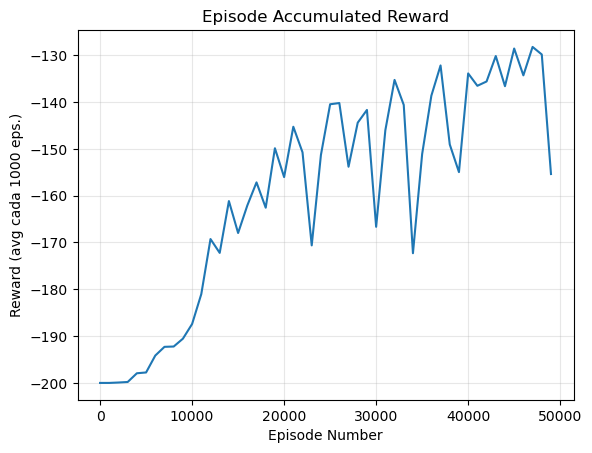

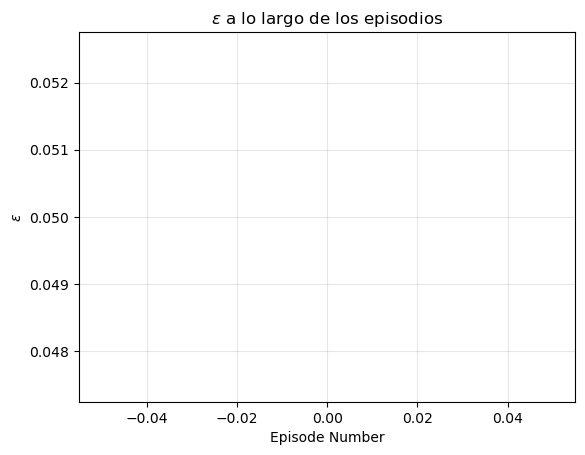

In [28]:
plot_rewards(rewards_ql)
plot_epsilon(epsilons_ql)

In [33]:
env_dis = get_env_discretized(record_video=True, record_every=1, folder="./videos/q_learning_test")

for episode_num in range(5):
    (pos, vel), info = env_dis.reset()
    episode_over = False
    while not episode_over:
        action = np.argmax(Q_ql[pos, vel])  # Exploit
        (pos, vel), reward, terminated, truncated, info = env_dis.step(action)
        episode_over = terminated or truncated

/home/jgayoso/anaconda3/envs/taller-ia/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


## SARSA
Sarsa es otro algoritmo de aprendizaje por refuerzo que, a diferencia de Q-Learning, es un método on-policy. Esto significa que el agente actualiza su tabla Q utilizando la acción que realmente toma en el entorno, lo que lo hace más sensible a la política actual. El algoritmo se basa en el siguiente algoritmo:

**Sutton & Barto, 2nd ed., §6.4 (p. 130).** Actualización on-policy:

$$
Q(S,A) \;\leftarrow\; Q(S,A) \;+\; \alpha\Bigl[\,R + \gamma\,Q(S',A') \;-\; Q(S,A)\Bigr]
$$

$$
\begin{aligned}
&\textbf{Sarsa (On-Policy TD Control)}\\[4pt]
&\textbf{Parámetros: } \alpha \in (0,1],\ \varepsilon > 0,\ \gamma \in (0,1].\\
&\textbf{Inicializar: } Q(s,a)\ \text{arbitrario};\ Q(\text{terminal},\cdot) \leftarrow 0.\\
&\textbf{Loop por cada episodio:}\\
&\quad \text{Inicializar } S;\ A \leftarrow \pi_\varepsilon(S).\\
&\quad \textbf{mientras } S \text{ no sea terminal:}\\
&\quad\quad \text{Ejecutar } A,\ \text{observar } R,\ S'.\\
&\quad\quad A' \leftarrow \pi_\varepsilon(S').\\
&\quad\quad Q(S,A) \leftarrow Q(S,A) + \alpha\bigl[R + \gamma\,Q(S',A') - Q(S,A)\bigr].\\
&\quad\quad S \leftarrow S',\ A \leftarrow A'.
\end{aligned}
$$

> **Diferencia clave con Q-Learning.** El target usa $Q(S', A')$ con $A' \sim \pi_\varepsilon$
> en lugar de $\max_a Q(S', a)$. Por eso Sarsa **evalúa la política que efectivamente
> sigue** (incluyendo la exploración), mientras que Q-Learning aprende la política
> greedy óptima $\pi_*$ independientemente de la política de comportamiento.


SARSA usa la misma politica que usa para recorrer que va actualizando mientras va aprendiendo.

In [ ]:
def sarsa(env, num_episodes=1000, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.9995, epsilon_min=0.05):
    """
    Sarsa on-policy (Sutton & Barto, sec. 6.4).

    Args:
        env          : ambiente discretizado.
        num_episodes : cantidad de episodios de entrenamiento.
        alpha        : tasa de aprendizaje, en (0, 1].
        gamma        : factor de descuento, en (0, 1].
        epsilon_*    : exploracion con decaimiento exponencial.

    Returns:
        Q              (np.ndarray): tabla aprendida, shape (NUMBER_STATES, NUMBER_STATES, n_actions).
        episode_rewards(list[float]): retorno acumulado por episodio.
        epsilons       (list[float]): valor de epsilon usado en cada episodio.
    """
    Q = np.zeros((NUMBER_STATES, NUMBER_STATES, env.action_space.n), dtype=np.float32)
    episode_rewards, epsilons = [], []
    epsilon = epsilon_start
    pbar = tqdm(range(num_episodes), desc="SARSA")
    for episode in pbar:
        G = 0
        (pos, vel), _ = env.reset()
        action = select_action(env, Q, pos, vel, epsilon)
        done = False
        while not done:
            (pos_next, vel_next), reward, terminated, truncated, _ = env.step(action)

            G += reward
            action_next = select_action(env, Q, pos_next, vel_next, epsilon)
            td_target = reward + gamma*Q[pos_next, vel_next, action_next]
            Q[pos, vel, action] += alpha*(td_target - Q[pos, vel, action])
            pos, vel = pos_next, vel_next
            action = action_next
            done = terminated or truncated

        episode_rewards.append(G)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon*epsilon_decay)

        if (episode + 1) % 50 == 0:
            recent_rewards = np.mean(episode_rewards[-50:])
            pbar.set_postfix(rewards=recent_rewards, eps=epsilon)

    return Q, episode_rewards, epsilons

In [30]:
env_dis = get_env_discretized(record_video=True, record_every=1_000, folder="./videos/sarsa_training")
Q_sarsa, rewards_sarsa, epsilons_sarsa = sarsa(env_dis, num_episodes=NUMBER_EPISODES)

SARSA: 100%|██████████| 50000/50000 [04:36<00:00, 180.73it/s, eps=0.05, rewards=-141] 


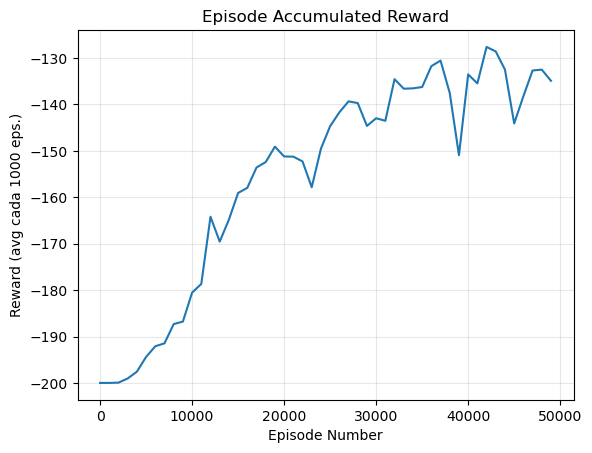

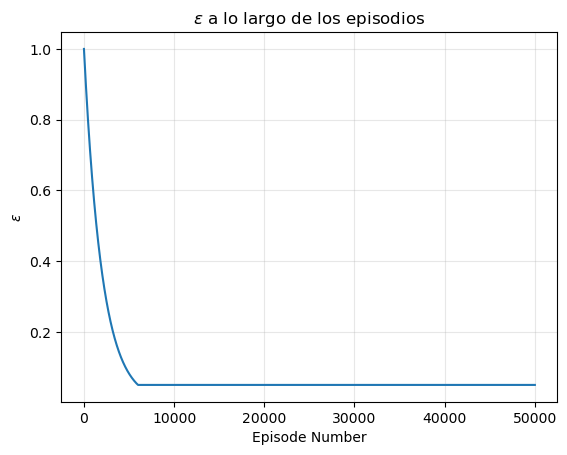

In [31]:
plot_rewards(rewards_sarsa)
plot_epsilon(epsilons_sarsa)

In [32]:
env_dis = get_env_discretized(record_video=True, record_every=1, folder="./videos/sarsa_test")

for episode_num in range(5):
    (pos, vel), info = env_dis.reset()
    episode_over = False
    while not episode_over:
        action = np.argmax(Q_sarsa[pos, vel])  # Exploit
        (pos, vel), reward, terminated, truncated, info = env_dis.step(action)
        episode_over = terminated or truncated

### Comparación Q-Learning vs Sarsa en MountainCar

Ambas curvas suavizadas con media móvil sobre el mismo eje:


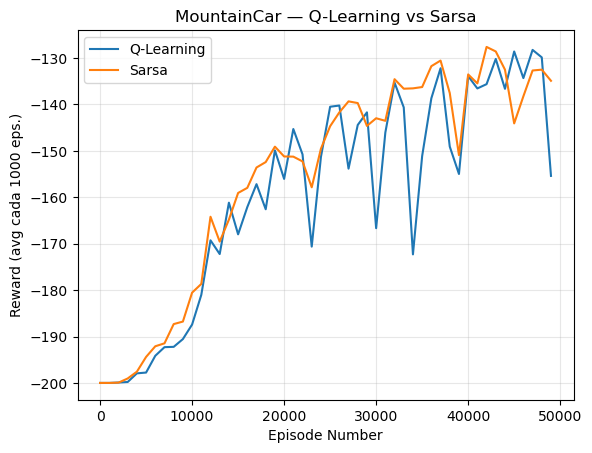

In [34]:
plot_rewards_comparison([rewards_ql, rewards_sarsa],
                        labels=["Q-Learning", "Sarsa"],
                        title="MountainCar — Q-Learning vs Sarsa")

## Tareas

1. Implementar tanto el algoritmo de **Q-Learning** como el de **Sarsa** para estimar $Q^*$ en MountainCar (sección anterior).
2. Implementar el experimento de **Cliff Walking** (Sutton & Barto §6.5, Fig. 6.4) para comparar ambos algoritmos. Analizar y discutir los resultados: identificar cuál de los dos algoritmos tiende a *caminar por el borde* (más arriesgado) y cuál es más cauteloso, justificando la diferencia a partir del target de la actualización TD. Usar [CliffWalking](https://gymnasium.farama.org/environments/toy_text/cliff_walking/).
3. *(Opcional)* Resolver FrozenLake-v1 con is_slippery=True con ambos algoritmos.